# Tech Challenge - Fase 1

## Desafio

Um grande hospital universitário busca implementar um sistema inteligente de suporte ao diagnóstico, capaz de ajudar médicos e equipes clínicas na análise inicial de exames e no processamento de dados médicos.

Com um volume crescente de pacientes e exames, como radiografias, tomografias, ressonâncias e prontuários digitalizados, o hospital precisa de soluções que acelerem a triagem e apoiem as decisões médicas, reduzindo erros e otimizando o tempo dos profissionais.

Nesta primeira fase, o desafio é criar a base do sistema de IA focado em machine learning, permitindo que resultados de exames sejam analisados automaticamente e destacando informações relevantes para o diagnóstico.

## Objetivo

Construir uma solução inicial com foco em IA para processamento de exames médicos e documentos clínicos, aplicando fundamentos essenciais de IA, Machine Learning e Visão Computacional.

## Patologia escolhida para o desafio: Acidente Vascular Cerebral (AVC)

### O que é o AVC

O Acidente Vascular Cerebral (AVC) é uma condição em que o fluxo de sangue para uma parte do cérebro é interrompido. Como as células cerebrais dependem de oxigênio e nutrientes trazidos pelo sangue, essa interrupção pode causar danos neurológicos em poucos minutos.

### Tipos de AVC

1. AVC Isquêmico

- Ocorre quando um vaso sanguíneo é bloqueado por um coágulo.
- É o tipo mais comum.
- Geralmente relacionado a aterosclerose, fibrilação atrial e fatores de risco cardiovasculares.

2. AVC Hemorrágico
- Acontece quando um vaso sanguíneo se rompe, causando sangramento no cérebro.
- Pode ser causado por hipertensão não controlada, aneurismas ou malformações vasculares.

### Base de Dados - NHANES (https://www.cdc.gov/nchs/nhanes)

O NHANES (National Health and Nutrition Examination Survey) é uma base de dados pública conduzida pelo CDC (Centers for Disease Control and Prevention) dos Estados Unidos, voltada à avaliação do estado de saúde e nutricional da população norte-americana.

De forma breve:

- Natureza: estudo observacional, transversal, com amostragem probabilística representativa da população dos EUA.

- Periodicidade: realizado continuamente, organizado em ciclos bienais (ex.: 2017–2018 https://wwwn.cdc.gov/Nchs/Nhanes/continuousnhanes/default.aspx?BeginYear=2017).

- Conteúdo: combina

    - Questionários (doenças autorreferidas, estilo de vida, tabagismo, diabetes, histórico de AVC),

    - Exames físicos (pressão arterial, IMC, medidas corporais),

    - Exames laboratoriais (glicemia, hemoglobina glicada, colesterol, triglicerídeos, marcadores inflamatórios).

- Formato dos dados: arquivos modulares (.XPT), integrados por um identificador único do participante (SEQN).

- Aspecto metodológico importante: inclui pesos amostrais e variáveis de desenho complexo, permitindo inferência populacional.

No contexto acadêmico, o NHANES é amplamente utilizado para modelagem de risco cardiovascular e de AVC, epidemiologia, análise de fatores de risco e aplicações de machine learning em saúde, sendo valorizado pela qualidade dos dados, transparência metodológica e acesso aberto.

**Importando a base de dados**

In [46]:
import pandas as pd  # importa a biblioteca pandas

pd.set_option('display.max_columns', None)  # configura o pandas para mostrar todas as colunas ao exibir DataFrames

import pandas as pd  # importa a biblioteca pandas

pd.set_option('display.max_columns', None)  # configura o pandas para mostrar todas as colunas ao exibir DataFrames

cycle_map = {
    "2011-2012": "G",
    "2013-2014": "H",
    "2015-2016": "I",
    "2017-2018": "J"
}

modules = {  # dicionário que mapeia nomes lógicos para templates de arquivos XPT
    "demo": "DEMO_{}.XPT",  # arquivo DEMO (dados demográficos): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.htm (ajustado para usar a letra do ciclo)
    "bpx": "BPX_{}.XPT",     # arquivo BPX (medidas de pressão arterial): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPX_J.htm
    "bpq": "BPQ_{}.XPT", # arquivo BPQ (pressão arterial e colesterol): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPQ_J.htm
    "ocq": "OCQ_{}.XPT",     # arquivo OCQ (questionário de ocupação): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/OCQ_J.htm
    "ghb": "GHB_{}.XPT",     # arquivo GHB (hemoglobina glicada): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/GHB_J.htm
    "bmx": "BMX_{}.XPT",     # arquivo BMX (medidas corporais): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.htm
    "smq": "SMQ_{}.XPT",     # arquivo SMQ (questionário de tabagismo): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/SMQ_J.htm
    "mcq": "MCQ_{}.XPT"     # arquivo de questionário médico (histórico de doenças): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/MCQ_J.htm
}

dfs = {name: [] for name in modules}  # dicionário de listas para armazenar os DataFrames de cada módulo por ciclo

cycles = list(cycle_map.keys())  # lista de ciclos (ex.: ["2011-2012", "2017-2018"])

for cycle in cycles:
    letter = cycle_map[cycle]  # obtém a letra do ciclo (ex.: "G" para "2011-2012")
    year = cycle.split('-')[0]  # obtém o ano inicial do ciclo (ex.: "2011" para "2011-2012")
    base_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/" + year + "/DataFiles/"  # URL base para os arquivos NHANES, usando o ano inicial
    for name, file_template in modules.items():  # itera sobre (nome, template de arquivo) do dicionário modules
        file = file_template.format(letter)  # formata o template com a letra do ciclo (ex.: "DEMO_G.XPT")
        print(f"Carregando {file} para o ciclo {cycle}...")
        dfs[name].append(pd.read_sas(base_url + file))  # lê o arquivo XPT remoto e adiciona à lista de dfs[name]

# concatena os DataFrames de cada módulo de todos os ciclos
demo_df = pd.concat(dfs["demo"], ignore_index=True)
bpx_df = pd.concat(dfs["bpx"], ignore_index=True)
bpq_df = pd.concat(dfs["bpq"], ignore_index=True)
ocq_df = pd.concat(dfs["ocq"], ignore_index=True)
ghb_df = pd.concat(dfs["ghb"], ignore_index=True)
bmx_df = pd.concat(dfs["bmx"], ignore_index=True)
smq_df = pd.concat(dfs["smq"], ignore_index=True)
mcq_df = pd.concat(dfs["mcq"], ignore_index=True)

# inicia com o DataFrame 'demo' concatenado e faz merges left sucessivos com os outros DataFrames concatenados usando 'SEQN' como chave
df = demo_df \
    .merge(bpx_df, on="SEQN", how="left") \
    .merge(bpq_df, on="SEQN", how="left") \
    .merge(ocq_df, on="SEQN", how="left") \
    .merge(ghb_df, on="SEQN", how="left") \
    .merge(bmx_df, on="SEQN", how="left") \
    .merge(smq_df, on="SEQN", how="left") \
    .merge(mcq_df, on="SEQN", how="left")

df.head()  # exibe a forma (número de linhas e colunas) do DataFrame final combinado

df.head()  # exibe a forma (número de linhas e colunas) do DataFrame final combinado


Carregando DEMO_G.XPT para o ciclo 2011-2012...
Carregando BPX_G.XPT para o ciclo 2011-2012...
Carregando BPQ_G.XPT para o ciclo 2011-2012...
Carregando OCQ_G.XPT para o ciclo 2011-2012...
Carregando GHB_G.XPT para o ciclo 2011-2012...
Carregando BMX_G.XPT para o ciclo 2011-2012...
Carregando SMQ_G.XPT para o ciclo 2011-2012...
Carregando MCQ_G.XPT para o ciclo 2011-2012...
Carregando DEMO_H.XPT para o ciclo 2013-2014...
Carregando BPX_H.XPT para o ciclo 2013-2014...
Carregando BPQ_H.XPT para o ciclo 2013-2014...
Carregando OCQ_H.XPT para o ciclo 2013-2014...
Carregando GHB_H.XPT para o ciclo 2013-2014...
Carregando BMX_H.XPT para o ciclo 2013-2014...
Carregando SMQ_H.XPT para o ciclo 2013-2014...
Carregando MCQ_H.XPT para o ciclo 2013-2014...
Carregando DEMO_I.XPT para o ciclo 2015-2016...
Carregando BPX_I.XPT para o ciclo 2015-2016...
Carregando BPQ_I.XPT para o ciclo 2015-2016...
Carregando OCQ_I.XPT para o ciclo 2015-2016...
Carregando GHB_I.XPT para o ciclo 2015-2016...
Carregando

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGY,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGE,DMDHRBR4,DMDHREDU,DMDHRMAR,DMDHSEDU,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,PEASCST1,PEASCTM1,PEASCCT1,BPXCHR,BPQ150A,BPQ150B,BPQ150C,BPQ150D,BPAARM,BPACSZ,BPXPLS,BPXPULS,BPXPTY,BPXML1,BPXSY1,BPXDI1,BPAEN1,BPXSY2,BPXDI2,BPAEN2,BPXSY3,BPXDI3,BPAEN3,BPXSY4,BPXDI4,BPAEN4,BPQ020,BPQ030,BPD035,BPQ040A,BPQ050A,BPQ057,BPQ056,BPD058,BPQ059,BPQ080,BPQ060,BPQ070,BPQ090D,BPQ100D,OCD150,OCQ180,OCQ210,OCD231,OCD241,OCQ260,OCD270,OCQ275,OCQ380,OCD390G,OCD391,OCD392,OCD395,OCQ510,OCQ520,OCQ530,OCQ540,OCQ550,OCQ560,OCQ570,OCQ580,OCQ600,OCQ610,OCQ630,OCQ640,OCQ660,OCQ670,LBXGH,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,BMXBMI,BMDBMIC,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXSAD1,BMXSAD2,BMXSAD3,BMXSAD4,BMDAVSAD,BMDSADCM,BMXHIP,BMIHIP,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD055,SMD057,SMQ077,SMD641,SMD650,SMD093,SMDUPCA,SMD100BR,SMD100FL,SMD100MN,SMD100LN,SMD100TR,SMD100NI,SMD100CO,SMQ621,SMD630,SMQ660,SMQ664M,SMQ664C,SMQ664W,SMQ664B,SMQ664O,SMQ670,SMAQUEX2,SMQ078,SMQ661,SMQ665A,SMQ665B,SMQ665C,SMQ665D,SMQ848,SMQ852Q,SMQ852U,SMQ925,SMQ930,SMQ935,SMQ080,SMQ890,SMQ895,SMQ900,SMQ905,SMQ910,SMQ915,MCQ010,MCQ025,MCQ035,MCQ040,MCQ050,MCQ051,MCQ053,MCQ070,MCQ075,MCQ080,MCQ082,MCQ084,MCQ086,MCQ092,MCD093,MCQ140,MCQ149,MCQ160A,MCQ180A,MCQ195,MCQ160N,MCQ180N,MCQ160B,MCQ180B,MCQ160C,MCQ180C,MCQ160D,MCQ180D,MCQ160E,MCQ180E,MCQ160F,MCQ180F,MCQ160G,MCQ180G,MCQ160M,MCQ170M,MCQ180M,MCQ160K,MCQ170K,MCQ180K,MCQ160L,MCQ170L,MCQ180L,MCQ220,MCQ230A,MCQ230B,MCQ230C,MCQ230D,MCQ240A,MCQ240AA,MCQ240B,MCQ240BB,MCQ240C,MCQ240CC,MCQ240D,MCQ240DD,MCQ240DK,MCQ240E,MCQ240F,MCQ240G,MCQ240H,MCQ240I,MCQ240J,MCQ240K,MCQ240L,MCQ240M,MCQ240N,MCQ240O,MCQ240P,MCQ240Q,MCQ240R,MCQ240S,MCQ240T,MCQ240U,MCQ240V,MCQ240W,MCQ240X,MCQ240Y,MCQ240Z,MCQ300A,MCQ300B,MCQ300C,MCQ365A,MCQ365B,MCQ365C,MCQ365D,MCQ370A,MCQ370B,MCQ370C,MCQ370D,MCQ380,AGQ030,MCQ151,MCQ160O,MCQ203,MCQ206,OSQ230,RHD018,MCD180A,MCD180N,MCD180B,MCD180C,MCD180D,MCD180E,MCD180F,MCD180M,MCD180G,MCD180K,MCD180L,MCQ500,MCQ510A,MCQ510B,MCQ510C,MCQ510D,MCQ510E,MCQ510F,MCQ520,MCQ530,MCQ540,MCQ550,MCQ560,MCQ570,MCD240A,MCD240B,MCD240C,MCQ366A,MCQ366B,MCQ366C,MCQ366D,MCQ371A,MCQ371B,MCQ371C,MCQ371D
0,62161.0,7.0,2.0,1.0,22.0,NaN,3.0,3.0,2.0,NaN,NaN,2.0,NaN,1.0,1.0,NaN,NaN,3.0,5.0,NaN,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,102641.406474,104236.582554,1.0,91.0,14.0,14.0,3.15,5.0,5.0,5.397605e-79,1.0,5.397605e-79,2.0,50.0,1.0,5.0,1.0,5.0,NaN,NaN,NaN,NaN,1.0,596.0,NaN,NaN,2.0,2.0,2.0,2.0,1.0,4.0,82.0,1.0,1.0,130.0,110.0,82.0,2.0,104.0,68.0,2.0,118.0,74.0,2.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2.0,2.0,NaN,2.0,2.0,2.0,NaN,NaN,NaN,1.0,99999.0,2.0,16.0,14.0,4.0,12.0,2.0,NaN,2.0,NaN,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,5.1,1.0,69.2,NaN,NaN,NaN,NaN,NaN,172.3,NaN,23.3,NaN,40.2,NaN,35.0,NaN,32.5,NaN,81.0,NaN,17.7,17.9,NaN,NaN,17.8,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b'',b'',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,2.0,2.0,NaN,2.0,2.0,NaN,2.0,NaN,2.0,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,62162.0,7.0,2.0,2.0,3.0,NaN,1.0,1.0,1.0,3

In [47]:
df.shape

(39156, 328)

In [48]:
# manter somente as colunas solicitadas (se existirem) e avisar se alguma estiver ausente
cols_to_keep = [
    "SEQN", # Respondent sequence number
    "RIAGENDR", # Gender (DEMO_J): 1 - Male, 2 - Female
    "RIDAGEYR", # Age in years at screening (DEMO_J): 0 YEARS - 150 YEARS
    "BPQ020", # Ever told you had high blood pressure (BPQ_J): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "MCQ160B", # Ever told had congestive heart failure
    "MCQ160C", # Age when told you had heart failure
    "MCQ160D", # Age when told had coronary heart disease
    "MCQ160E", # Age when told you had angina pectoris
    "DMDMARTL", # Marital status
    "OCQ260", # Description of job/work situation
    "LBXGH", # Glycohemoglobin
    "BMXBMI", #  Body Mass Index (BMI)
    "SMQ020", # Smoked at least 100 cigarettes in life
    "MCQ160F" #  Ever told you had a stroke
]

missing = [c for c in cols_to_keep if c not in df.columns]
if missing:
    print("Aviso: colunas ausentes e que não foram selecionadas:", missing)

df = df[[c for c in cols_to_keep if c in df.columns]].copy()
df.shape

(39156, 14)

**Exploração de dados**

In [49]:
df.head(5)

,SEQN,RIAGENDR,RIDAGEYR,BPQ020,MCQ160B,MCQ160C,MCQ160D,MCQ160E,DMDMARTL,OCQ260,LBXGH,BMXBMI,SMQ020,MCQ160F
0,62161.0,1.0,22.0,2.0,2.0,2.0,2.0,2.0,5.0,4.0,5.1,23.3,2.0,2.0
1,62162.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.2,NaN,NaN
2,62163.0,1.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.5,17.3,NaN,NaN
3,62164.0,2.0,44.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,4.9,23.2,2.0,2.0
4,62165.0,2.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.9,27.2,NaN,NaN


In [50]:
# verificar as 20 colunas com mais valores ausentes
df.isnull().sum().sort_values(ascending=False).head(20)

OCQ260      25844
MCQ160B     16540
MCQ160F     16540
MCQ160E     16540
MCQ160D     16540
MCQ160C     16540
DMDMARTL    16539
SMQ020      15636
BPQ020      14030
LBXGH       13997
BMXBMI       4738
RIDAGEYR        0
SEQN            0
RIAGENDR        0
dtype: int64

In [51]:
# calcular o percentual de valores ausentes por coluna
total = len(df)
(df.isnull().sum() / total * 100).sort_values(ascending=False).head(20)

OCQ260      66.002656
MCQ160B     42.241291
MCQ160F     42.241291
MCQ160E     42.241291
MCQ160D     42.241291
MCQ160C     42.241291
DMDMARTL    42.238737
SMQ020      39.932577
BPQ020      35.831035
LBXGH       35.746757
BMXBMI      12.100317
RIDAGEYR     0.000000
SEQN         0.000000
RIAGENDR     0.000000
dtype: float64

<Axes: >

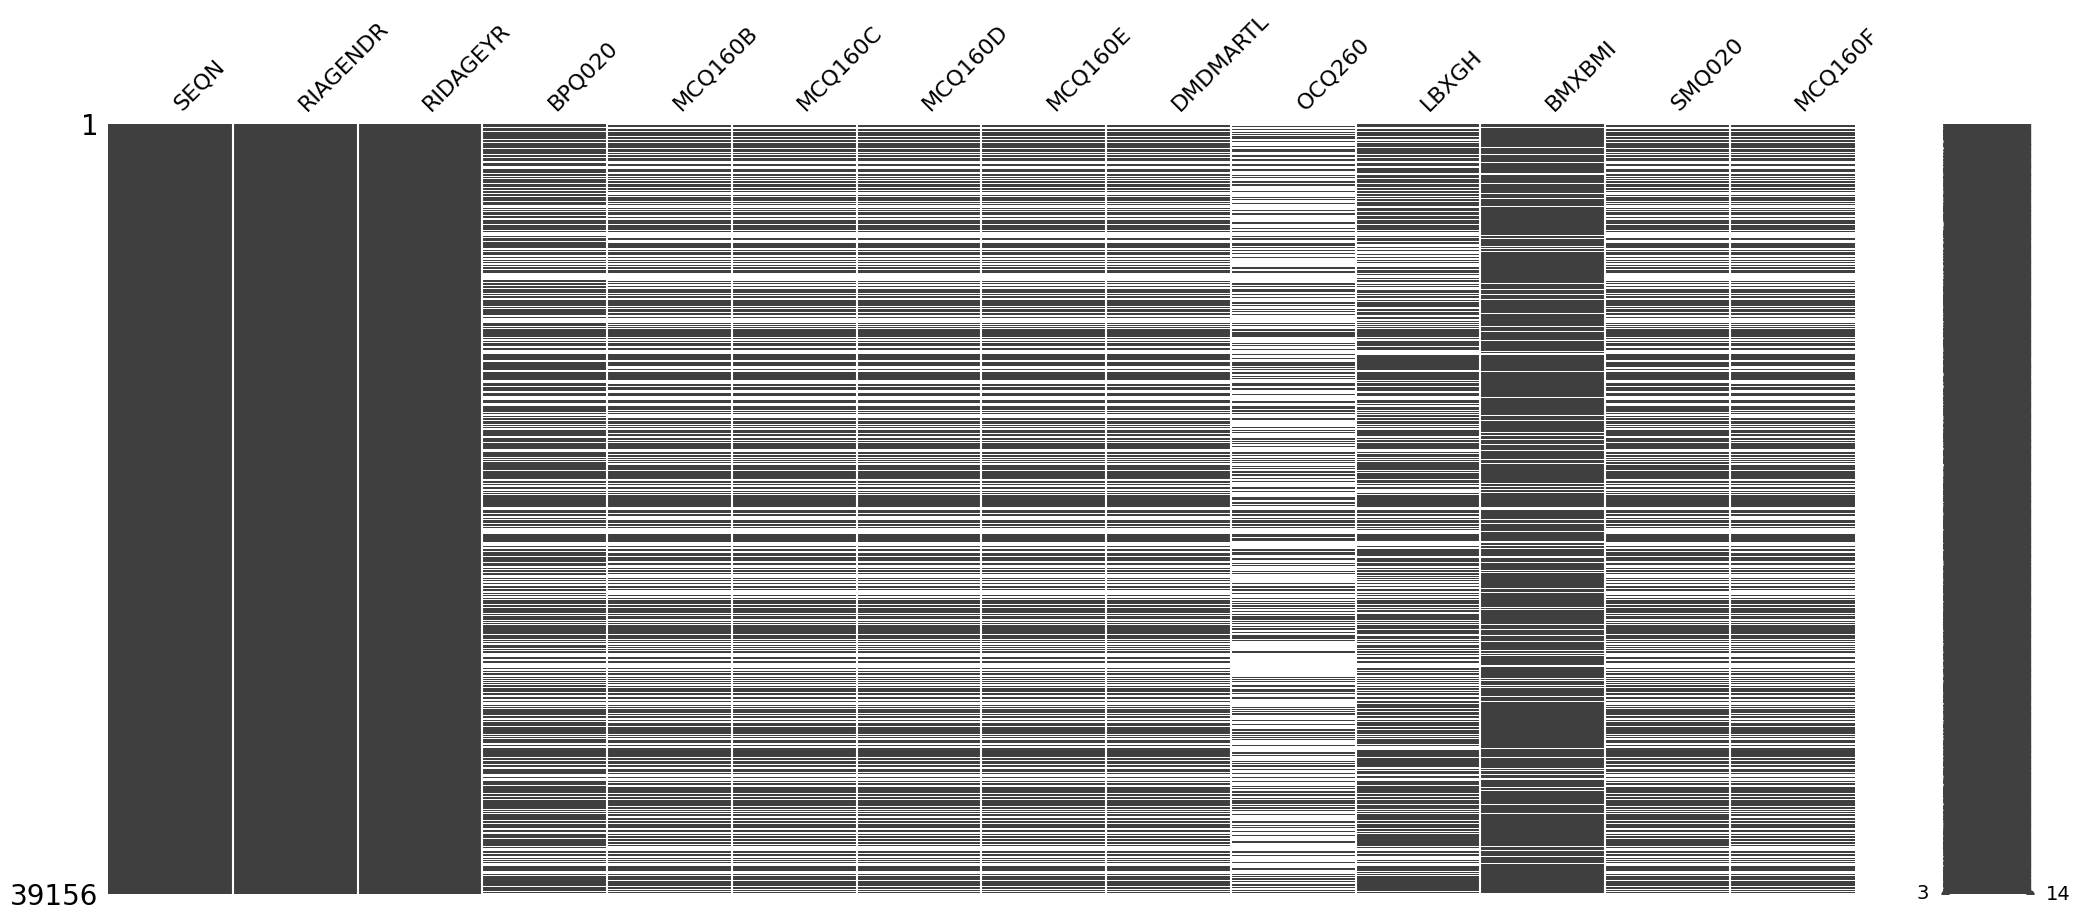

In [52]:
import missingno as msno
msno.matrix(df)

<Axes: >

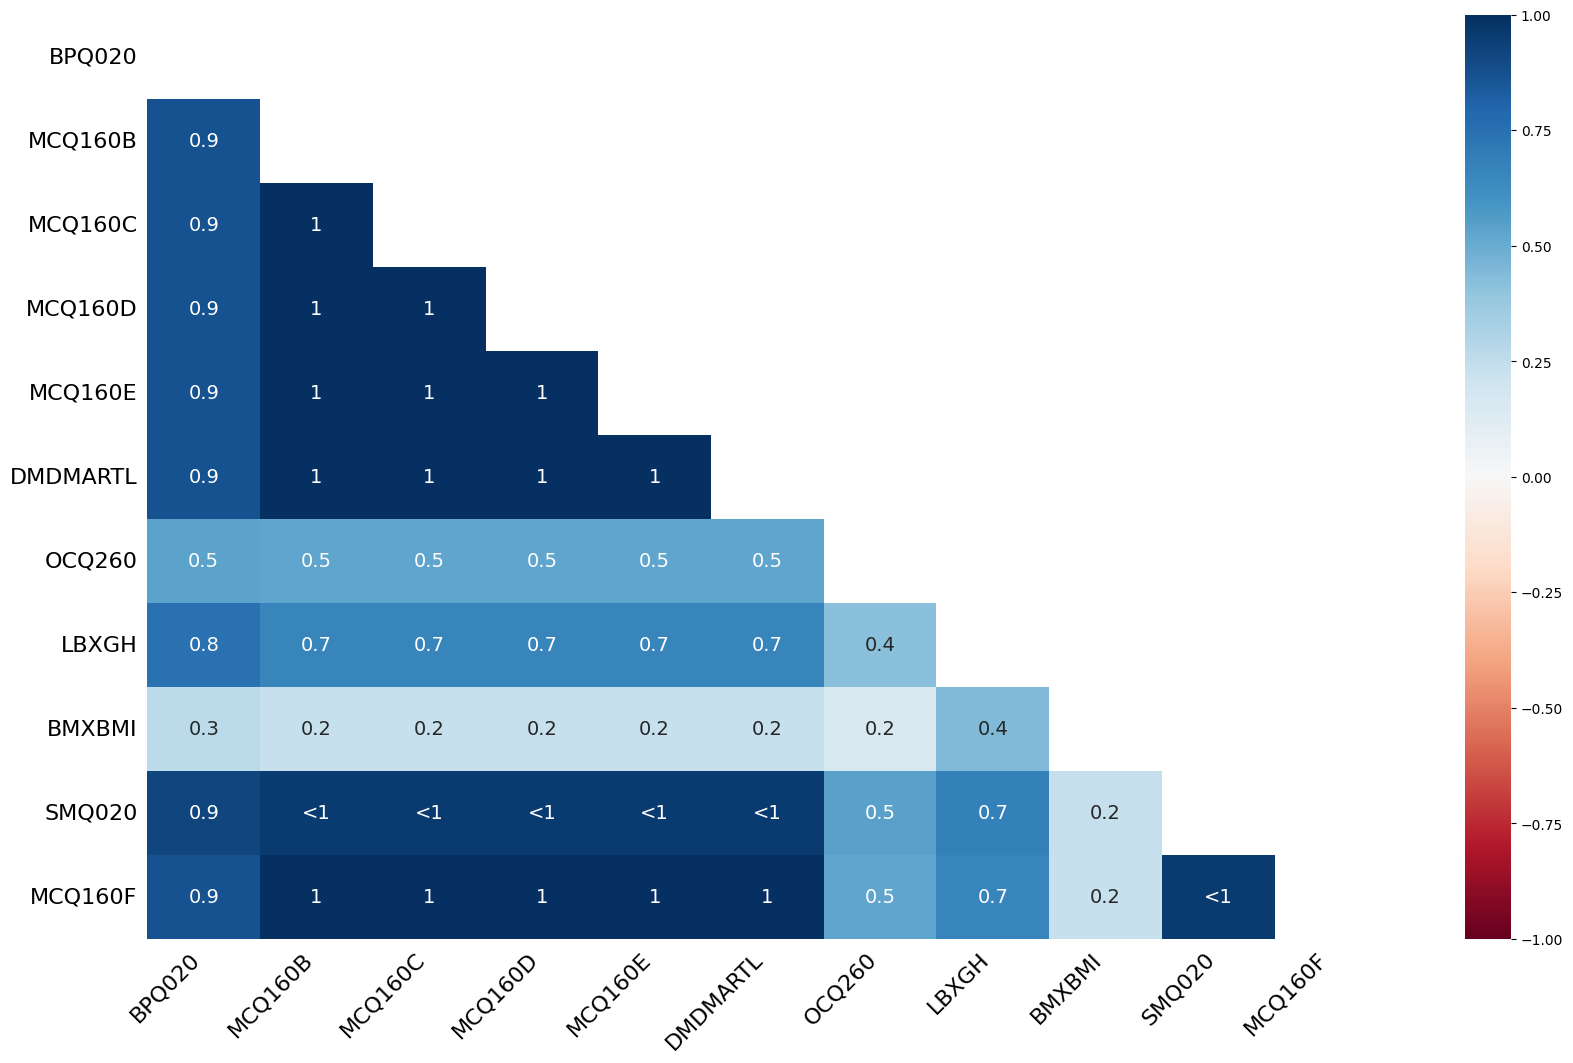

In [53]:
msno.heatmap(df)

In [54]:
df = df.dropna()
df.shape

(11446, 14)

In [55]:
df.info

<bound method DataFrame.info of            SEQN  RIAGENDR  RIDAGEYR  BPQ020  MCQ160B  MCQ160C  MCQ160D  \
0       62161.0       1.0      22.0     2.0      2.0      2.0      2.0   
3       62164.0       2.0      44.0     2.0      2.0      2.0      2.0   
18      62179.0       1.0      55.0     2.0      2.0      2.0      2.0   
19      62180.0       1.0      35.0     2.0      2.0      2.0      2.0   
23      62184.0       1.0      26.0     2.0      2.0      2.0      2.0   
...         ...       ...       ...     ...      ...      ...      ...   
39143  102944.0       1.0      55.0     1.0      2.0      2.0      2.0   
39146  102947.0       1.0      75.0     2.0      2.0      2.0      2.0   
39147  102948.0       2.0      31.0     2.0      2.0      2.0      2.0   
39148  102949.0       1.0      33.0     2.0      2.0      2.0      2.0   
39152  102953.0       1.0      42.0     2.0      2.0      2.0      2.0   

       MCQ160E  DMDMARTL  OCQ260  LBXGH  BMXBMI  SMQ020  MCQ160F  
0          2

## Referências

- https://pandascouple.medium.com/projeto-machine-learning-previs%C3%A3o-de-avc-f4b7dce11929
- https://jornal.usp.br/radio-usp/uso-de-ia-e-analise-de-dados-na-prevencao-de-avc-e-ataque-isquemico-transitorio/
- https://www-nature-com.translate.goog/articles/s41598-024-61665-4?error=cookies_not_supported&code=1d85f26e-6ade-4ec5-9132-5511aa615597&_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc
- https://jhi.sbis.org.br/index.php/jhi-sbis/article/view/980
